In [1]:
from ska_sdp_instrumental_calibration.scheduler import UpstreamOutput
from ska_sdp_instrumental_calibration.stages import (
    load_data_stage, predict_vis_stage, bandpass_calibration_stage, delay_calibration_stage
)
from ska_sdp_instrumental_calibration.data_managers.data_export import export_gaintable_to_h5parm
from ska_sdp_instrumental_calibration.numpy_processors.solvers import Solver
from ska_sdp_instrumental_calibration.plot import PlotGaintableFrequency
from ska_sdp_instrumental_calibration.xarray_processors._utils import parse_antenna
from ska_sdp_instrumental_calibration.xarray_processors.solver import run_solver
from ska_sdp_instrumental_calibration.stages._utils import get_gaintables_path, get_plots_path
from ska_sdp_instrumental_calibration.stages.configuration_models import PlotConfig
import dask

import numpy as np

input_ms = ["/data/SKA/inst_data/test_delay_visbility_240.ms"]
lsm_csv = "/data/SKA/inst_data/local_sky_model.csv"
output_dir = "./output_path"

upstream_output = UpstreamOutput()

In [2]:
def delay_calibration(
    upstream_output,
    output_path,
    refant = 0,
    niter = 200,
    tol  = 1e-06,
    export_gaintable = True,
):
    vis = upstream_output.vis
    modelvis = upstream_output.modelvis
    initialtable = upstream_output.gaintable
    prefix = upstream_output.ms_prefix

    refant = parse_antenna(refant, initialtable.configuration.names)
    solver = Solver.get_solver(refant=refant, niter=niter, tol=tol) # change

    gaintable = run_solver(  # update
        vis=vis,
        modelvis=modelvis,
        gaintable=initialtable,
        solver=solver,
    )

    if export_gaintable:
        gaintable_file_path = get_gaintables_path(
            output_path, f"{prefix}/bandpass_initialisation.gaintable.h5parm"
        )

        upstream_output["export_task"] = (
            dask.delayed(export_gaintable_to_h5parm)(
                gaintable, gaintable_file_path
            )
        )

    upstream_output["gaintable"] = gaintable
    upstream_output["refant"] = refant

    return upstream_output


In [3]:
upstream_output = load_data_stage(
    upstream_output,
    output_dir,
    input_ms=input_ms,
    cache_directory="../../output_wide_band_data",
)


params = {
    "lsm_csv_path": lsm_csv,
}

upstream_output = predict_vis_stage(
    upstream_output[0], output_dir, input_ms=input_ms, **params
)

visibility = upstream_output["vis"]
modelvis = upstream_output["modelvis"]
og_gaintable = upstream_output["gaintable"]

pols = ["XX", "YY"]
upstreams = []

for pol in pols:
    upstream_output["vis"] = visibility.sel(polarisation=[pol])
    upstream_output["modelvis"] = modelvis.sel(polarisation=[pol])
    upstream_output["gaintable"] = og_gaintable.sel(receptor1=[pol[0]], receptor2=[pol[0]])

    upstream_output = delay_calibration(
        upstream_output,
        output_dir
    )
    
    
    upstreams.append(upstream_output["gaintable"])



1|2026-06-18T12:36:05.232Z|INFO|upside-down|MainThread|_load_data|load_data.py#183||Reading cached visibilities from path ../../output_wide_band_data/test_delay_visbility_240.ms_fid0_ddid0
Successful readonly open of default-locked table /data/SKA/inst_data/test_delay_visbility_240.ms/FIELD: 9 columns, 1 rows
1|2026-06-18T12:36:05.292Z|INFO|upside-down|MainThread|__init__|local_sky_model.py#204||Generating GSM for predict with:
1|2026-06-18T12:36:05.292Z|INFO|upside-down|MainThread|__init__|local_sky_model.py#205|| - Search radius: 2.5 deg
1|2026-06-18T12:36:05.293Z|INFO|upside-down|MainThread|__init__|local_sky_model.py#206|| - Flux limit: 1.0 Jy
1|2026-06-18T12:36:05.293Z|INFO|upside-down|MainThread|__init__|local_sky_model.py#218|| - Catalogue file: /data/SKA/inst_data/local_sky_model.csv
1|2026-06-18T12:36:05.313Z|INFO|upside-down|MainThread|generate_lsm_from_csv|sky_model_reader.py#233||extracted 16 csv components
1|2026-06-18T12:36:05.313Z|INFO|upside-down|MainThread|__init__|loc

In [4]:
def get_gain_facet(gain_component, y_lim, y_label):
        """
        Create a facet grid scatter plot for a specific gain component.

        Parameters
        ----------
        gain_component : xarray.DataArray
            The gain data (e.g., amplitude or phase) to plot.
        y_lim : tuple or None
            Desired y-axis limits (e.g., `(-180, 180)`).
        y_label : str
            The label for the y-axis.

        Returns
        -------
        xarray.plot.FacetGrid
            The generated FacetGrid object.
        """
        plot_kwargs = dict(
            x="frequency",
            hue="Jones_Solutions",
            col="antenna",
            col_wrap=5,
            add_legend=True,
            add_colorbar=False,
            sharex=True,
            sharey=True,
            edgecolors="none",
            aspect=1.5,
            s=8,
        )
        facet_plot = gain_component.plot.scatter(
            **plot_kwargs, ylim=y_lim
        )

        return facet_plot
    

def plot_bandpass_terms(
        gaintable,
        figure_title,
        output_dir
    ):
        sol_term = "xx-plot"
        figure_sub_title = sol_term.capitalize()
        gain_phase = gaintable.gain.copy()
        gain_phase.data = np.angle(gaintable.gain, deg=True)
        ylim = (-180, 180)
        gain_phase_fig = get_gain_facet(
            gain_phase, ylim, "Phase (degree)"
        ).fig

        gain_phase_fig.suptitle(
            f"{figure_title} {figure_sub_title} Solutions (Phase)"
            f"plottitle",
            fontsize="x-large",
            y=1.02,
        )
        gain_phase_fig.tight_layout()

        gain_phase_fig.savefig(
            f"{output_dir}/delay_plot.png",
            bbox_inches="tight",
        )

        plt.show()


In [5]:
import pandas as pd

def unstack_jones_coordinate(ref_gaintable, gaintable):
    stack_gains = gaintable.gain.data
    new_gain_data = ref_gaintable.gain.data.copy()
    new_gain_data[..., 0, 0] = stack_gains[..., 0]
    new_gain_data[..., 1, 1] = stack_gains[..., 1]

    new_gain = ref_gaintable.gain.copy()
    new_gain.data = new_gain_data

    return ref_gaintable.assign(
        {
            "gain": new_gain,
        }
    ).chunk(ref_gaintable.chunks)
    
    
def stack_jones_coordinate(gaintable):
    gaintable = gaintable.stack(Jones_Solutions=("receptor1", "receptor2"))

    polstrs = [
        f"J_{p1}{p2}".upper()
        for p1, p2 in gaintable["Jones_Solutions"].data
    ]
    gaintable = gaintable.drop_vars(['Jones_Solutions', 'receptor1', 'receptor2']).assign_coords({"Jones_Solutions": polstrs})

    return gaintable


In [6]:
import xarray as xr
gaintable1 = stack_jones_coordinate(upstreams[0])
gaintable2 = stack_jones_coordinate(upstreams[1])
gaintable = xr.merge([gaintable1, gaintable2])

1|2026-06-18T12:36:07.845Z|INFO|upside-down|ThreadPoolExecutor-0_7|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:36:07.949Z|INFO|upside-down|ThreadPoolExecutor-0_5|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:36:07.950Z|INFO|upside-down|ThreadPoolExecutor-0_12|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:36:07.990Z|INFO|upside-down|ThreadPoolExecutor-0_6|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:36:08.010Z|INFO|upside-down|ThreadPoolExecutor-0_3|__init__|beams.py#126||Setting beam normalisation for OSKAR data


2026-06-18 12:36:08	SEVERE	MeasTable::dUTC(Double) (file /tmp/casacore-3.7.1/measures/Measures/MeasTable.cc, line 4290)	Leap second table TAI_UTC seems out-of-date.
2026-06-18 12:36:08	SEVERE	MeasTable::dUTC(Double) (file /tmp/casacore-3.7.1/measures/Measures/MeasTable.cc, line 4290)+	Until the table is updated (see the CASA documentation or your system admin),
2026-06-18 12:36:08	SEVERE	MeasTable::dUTC(Double) (file /tmp/casacore-3.7.1/measures/Measures/MeasTable.cc, line 4290)+	times and coordinates derived from UTC could be wrong by 1s or more.


1|2026-06-18T12:36:09.032Z|INFO|upside-down|ThreadPoolExecutor-0_20|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:36:09.056Z|INFO|upside-down|ThreadPoolExecutor-0_18|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:36:09.057Z|INFO|upside-down|ThreadPoolExecutor-0_9|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:36:09.082Z|INFO|upside-down|ThreadPoolExecutor-0_12|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:36:09.109Z|INFO|upside-down|ThreadPoolExecutor-0_1|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:36:10.270Z|INFO|upside-down|ThreadPoolExecutor-0_3|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:36:10.361Z|INFO|upside-down|ThreadPoolExecutor-0_5|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:36:10.389Z|INFO|upside-down|ThreadPoolExecutor-0_14|__ini

In [11]:
gaintable = gaintable.compute()

1|2026-06-18T12:39:49.526Z|INFO|upside-down|ThreadPoolExecutor-0_18|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:39:49.661Z|INFO|upside-down|ThreadPoolExecutor-0_14|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:39:49.661Z|INFO|upside-down|ThreadPoolExecutor-0_2|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:39:49.661Z|INFO|upside-down|ThreadPoolExecutor-0_9|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:39:49.661Z|INFO|upside-down|ThreadPoolExecutor-0_11|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:39:49.790Z|INFO|upside-down|ThreadPoolExecutor-0_4|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:39:49.855Z|INFO|upside-down|ThreadPoolExecutor-0_1|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:39:49.905Z|INFO|upside-down|ThreadPoolExecutor-0_0|__init

1|2026-06-18T12:37:26.799Z|INFO|upside-down|ThreadPoolExecutor-0_20|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:37:26.879Z|INFO|upside-down|ThreadPoolExecutor-0_18|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:37:26.898Z|INFO|upside-down|ThreadPoolExecutor-0_1|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:37:26.907Z|INFO|upside-down|ThreadPoolExecutor-0_17|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:37:26.960Z|INFO|upside-down|ThreadPoolExecutor-0_10|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:37:27.086Z|INFO|upside-down|ThreadPoolExecutor-0_19|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:37:27.151Z|INFO|upside-down|ThreadPoolExecutor-0_7|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:37:27.192Z|INFO|upside-down|ThreadPoolExecutor-0_0|__in

/home/justin/miniconda3/envs/inst/lib/python3.10/site-packages/matplotlib/colors.py:2243: UserWarning: Warning: converting a masked element to nan.
  dtype = np.min_scalar_type(value)
/home/justin/miniconda3/envs/inst/lib/python3.10/site-packages/matplotlib/colors.py:2250: UserWarning: Warning: converting a masked element to nan.
  data = np.asarray(value)


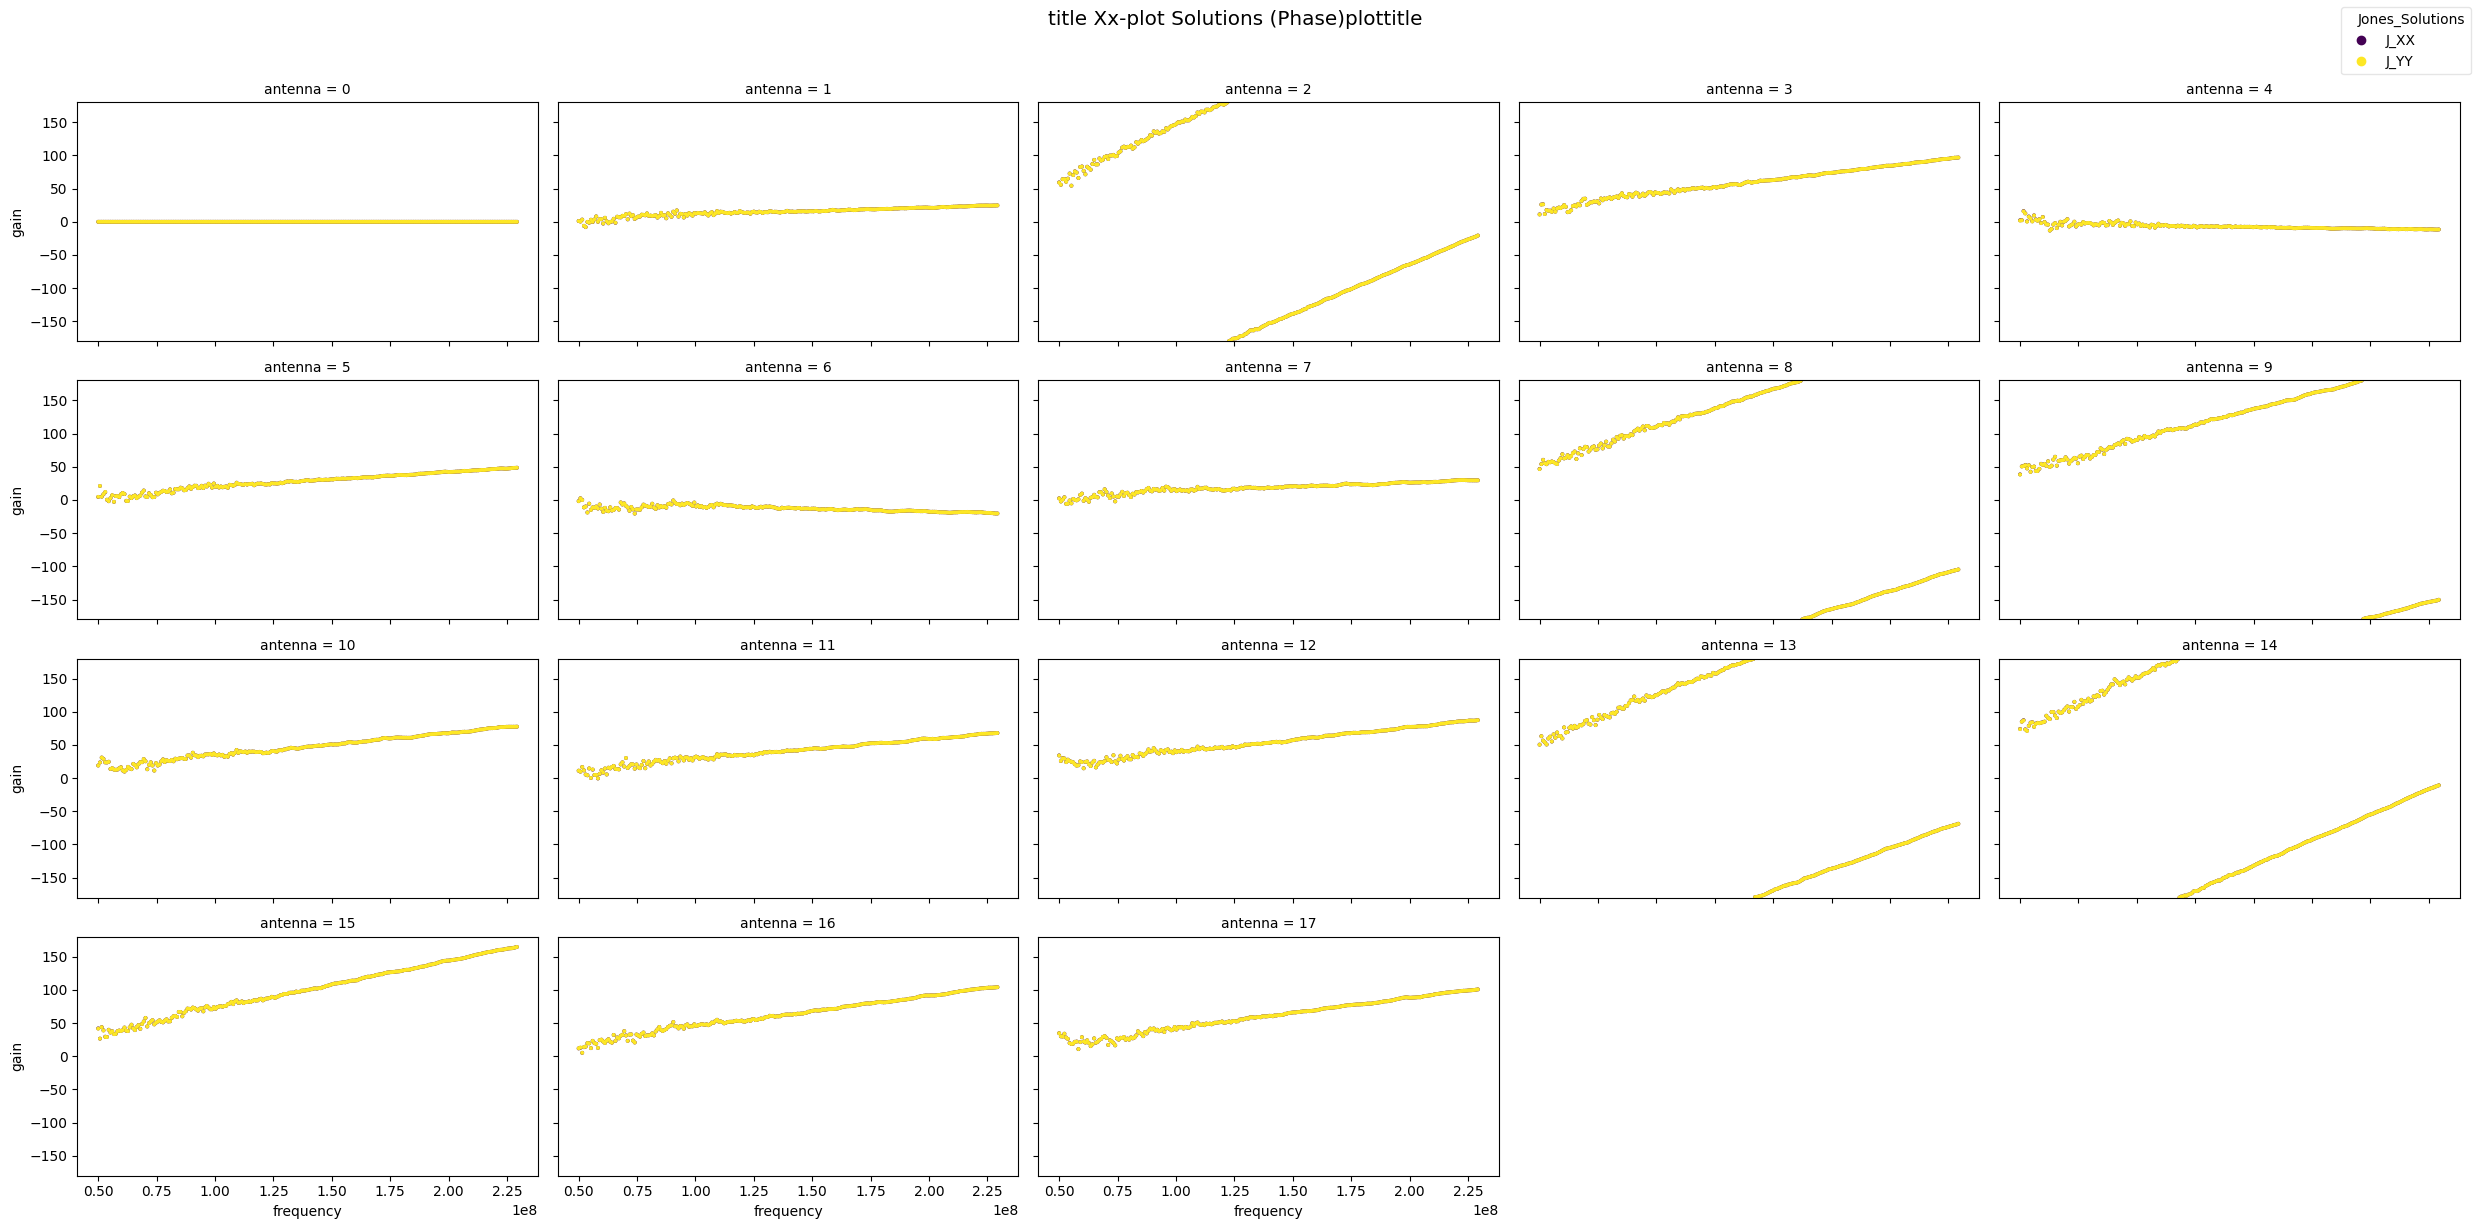

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
plot_bandpass_terms(gaintable, "title", output_dir)

In [8]:
gaintable = unstack_jones_coordinate(og_gaintable, gaintable)
gaintable

<xarray.GainTable> Size: 213kB
Dimensions:    (time: 1, antenna: 18, frequency: 240, receptor1: 2, receptor2: 2)
Coordinates:
  * time       (time) float64 8B 4.454e+09
  * antenna    (antenna) int64 144B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
  * frequency  (frequency) float64 2kB 5e+07 5.075e+07 ... 2.285e+08 2.292e+08
  * receptor1  (receptor1) <U1 8B 'X' 'Y'
  * receptor2  (receptor2) <U1 8B 'X' 'Y'
Data variables:
    gain       (time, antenna, frequency, receptor1, receptor2) complex64 138kB dask.array<chunksize=(1, 18, 32, 2, 2), meta=np.ndarray>
    weight     (time, antenna, frequency, receptor1, receptor2) float32 69kB dask.array<chunksize=(1, 18, 32, 2, 2), meta=np.ndarray>
    residual   (time, frequency, receptor1, receptor2) float32 4kB dask.array<chunksize=(1, 32, 2, 2), meta=np.ndarray>
    interval   (time) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    datetime   (time) datetime64[ns] 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    data_model:            GainTable
    receptor_frame1:       <ska_sdp_datamodels.science_data_model.polarisatio...
    receptor_frame2:       <ska_sdp_datamodels.science_data_model.polarisatio...
    phasecentre:           <SkyCoord (ICRS): (ra, dec) in deg\n    (197.91461...
    configuration:         <xarray.Configuration> Size: 4kB\nDimensions:   (i...
    jones_type:            B
    soln_interval_slices:  [slice(np.int64(0), np.int64(20), np.int64(1))]

In [12]:
from ska_sdp_instrumental_calibration.xarray_processors.delay import apply_delay, calculate_delay
from ska_sdp_instrumental_calibration.plot import plot_station_delays
def delay_calibration_stage(
    _upstream_output_,
    _qa_dir_,
    plot_config,
    oversample = 1,
    export_gaintable = True,
):

    gaintable = _upstream_output_["gaintable"]
    prefix = _upstream_output_.ms_prefix

    call_counter_suffix = ""
    if call_count := _upstream_output_.get_call_count("delay"):
        call_counter_suffix = f"_{call_count}"

    delaytable = calculate_delay(gaintable, oversample)

    gaintable = apply_delay(gaintable, delaytable)

    if plot_config.plot_table:
        path_prefix = get_plots_path(
            _qa_dir_, f"{prefix}/delay{call_counter_suffix}"
        )

        # freq_plotter = PlotGaintableFrequency(
        #     path_prefix=path_prefix,
        #     refant=_upstream_output_.refant,
        # )

        # _upstream_output_.add_compute_tasks(
        #     *freq_plotter.plot(
        #         gaintable,
        #         figure_title="Delay",
        #         fixed_axis=plot_config.fixed_axis,
        #     )
        # )

        _upstream_output_.add_compute_tasks(
            plot_station_delays(
                delaytable,
                path_prefix,
            )
        )

    # if export_gaintable:
    #     gaintable_file_path = get_gaintables_path(
    #         _qa_dir_,
    #         f"{prefix}/delay{call_counter_suffix}.gaintable.h5parm",
    #     )

    #     delaytable_file_path = get_gaintables_path(
    #         _qa_dir_, f"{prefix}/delay{call_counter_suffix}.clock.h5parm"
    #     )

    #     _upstream_output_.add_compute_tasks(
    #         dask.delayed(export_gaintable_to_h5parm)(
    #             gaintable, gaintable_file_path
    #         )
    #     )

    #     _upstream_output_.add_compute_tasks(
    #         export_clock_to_h5parm(delaytable, delaytable_file_path)
    #     )

    _upstream_output_["gaintable"] = gaintable

    return _upstream_output_


In [13]:
plot_config = PlotConfig()
upstream_output["gaintable"] = gaintable
xx = delay_calibration_stage(upstream_output, output_dir, plot_config)

/home/justin/miniconda3/envs/inst/lib/python3.10/site-packages/xarray/core/common.py:181: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.array(self.values, dtype=dtype, copy=copy)
/home/justin/miniconda3/envs/inst/lib/python3.10/site-packages/xarray/core/common.py:181: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.array(self.values, dtype=dtype, copy=copy)


1|2026-06-18T12:38:56.755Z|INFO|upside-down|ThreadPoolExecutor-0_3|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:38:56.755Z|INFO|upside-down|ThreadPoolExecutor-0_17|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:38:56.814Z|INFO|upside-down|ThreadPoolExecutor-0_1|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:38:56.847Z|INFO|upside-down|ThreadPoolExecutor-0_12|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:38:57.091Z|INFO|upside-down|ThreadPoolExecutor-0_21|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:38:57.124Z|INFO|upside-down|ThreadPoolExecutor-0_7|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:38:57.148Z|INFO|upside-down|ThreadPoolExecutor-0_10|__init__|beams.py#126||Setting beam normalisation for OSKAR data
1|2026-06-18T12:38:57.189Z|INFO|upside-down|ThreadPoolExecutor-0_4|__ini

/home/justin/Documents/Projects/SKA/ska-sdp-instrumental-calibration/src/ska_sdp_instrumental_calibration/plot/plot_gaintable.py:487: FutureWarning: updating coordinate 'Jones_Solutions' with a PandasMultiIndex would leave the multi-index level coordinates ['receptor1', 'receptor2'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['Jones_Solutions', 'receptor1', 'receptor2'])` before assigning new coordinate values.
  gaintable = gaintable.assign_coords({"Jones_Solutions": polstrs})
/home/justin/Documents/Projects/SKA/ska-sdp-instrumental-calibration/src/ska_sdp_instrumental_calibration/plot/plot_gaintable.py:487: FutureWarning: updating coordinate 'Jones_Solutions' with a PandasMultiIndex would leave the multi-index level coordinates ['receptor1', 'receptor2'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['Jones_Solutions', 'receptor1', 'receptor2'])` before assigning new coordinate values.
  gaintable = gaintable.

1|2026-06-18T12:39:46.583Z|INFO|upside-down|ThreadPoolExecutor-0_13|_plot_bandpass_terms|plot_gaintable.py#253||Gaintable plots saved with prefix ./output_path/plots/test_delay_visbility_240/delay.
1|2026-06-18T12:39:47.215Z|INFO|upside-down|ThreadPoolExecutor-0_21|_plot_bandpass_terms|plot_gaintable.py#253||Gaintable plots saved with prefix ./output_path/plots/test_delay_visbility_240/delay.


(None, None, None)

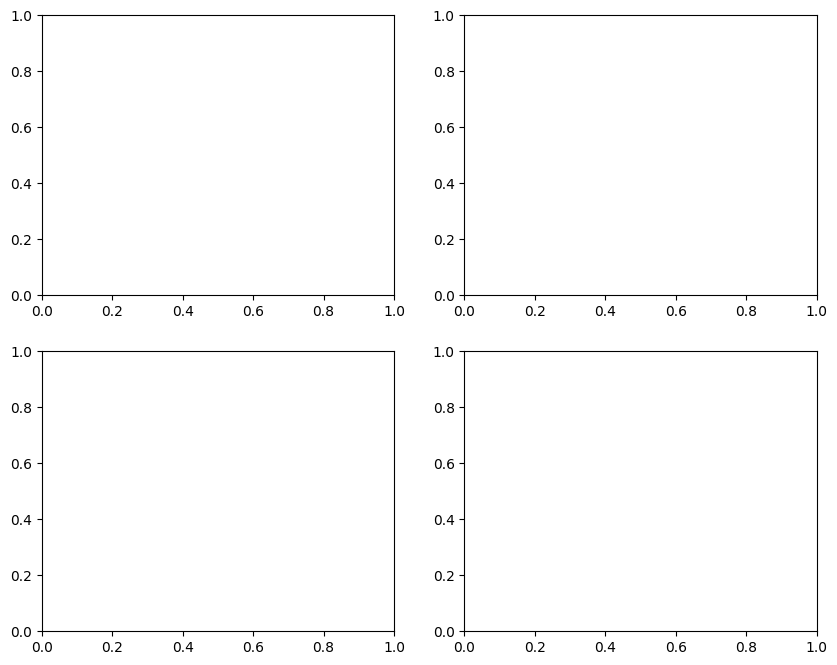

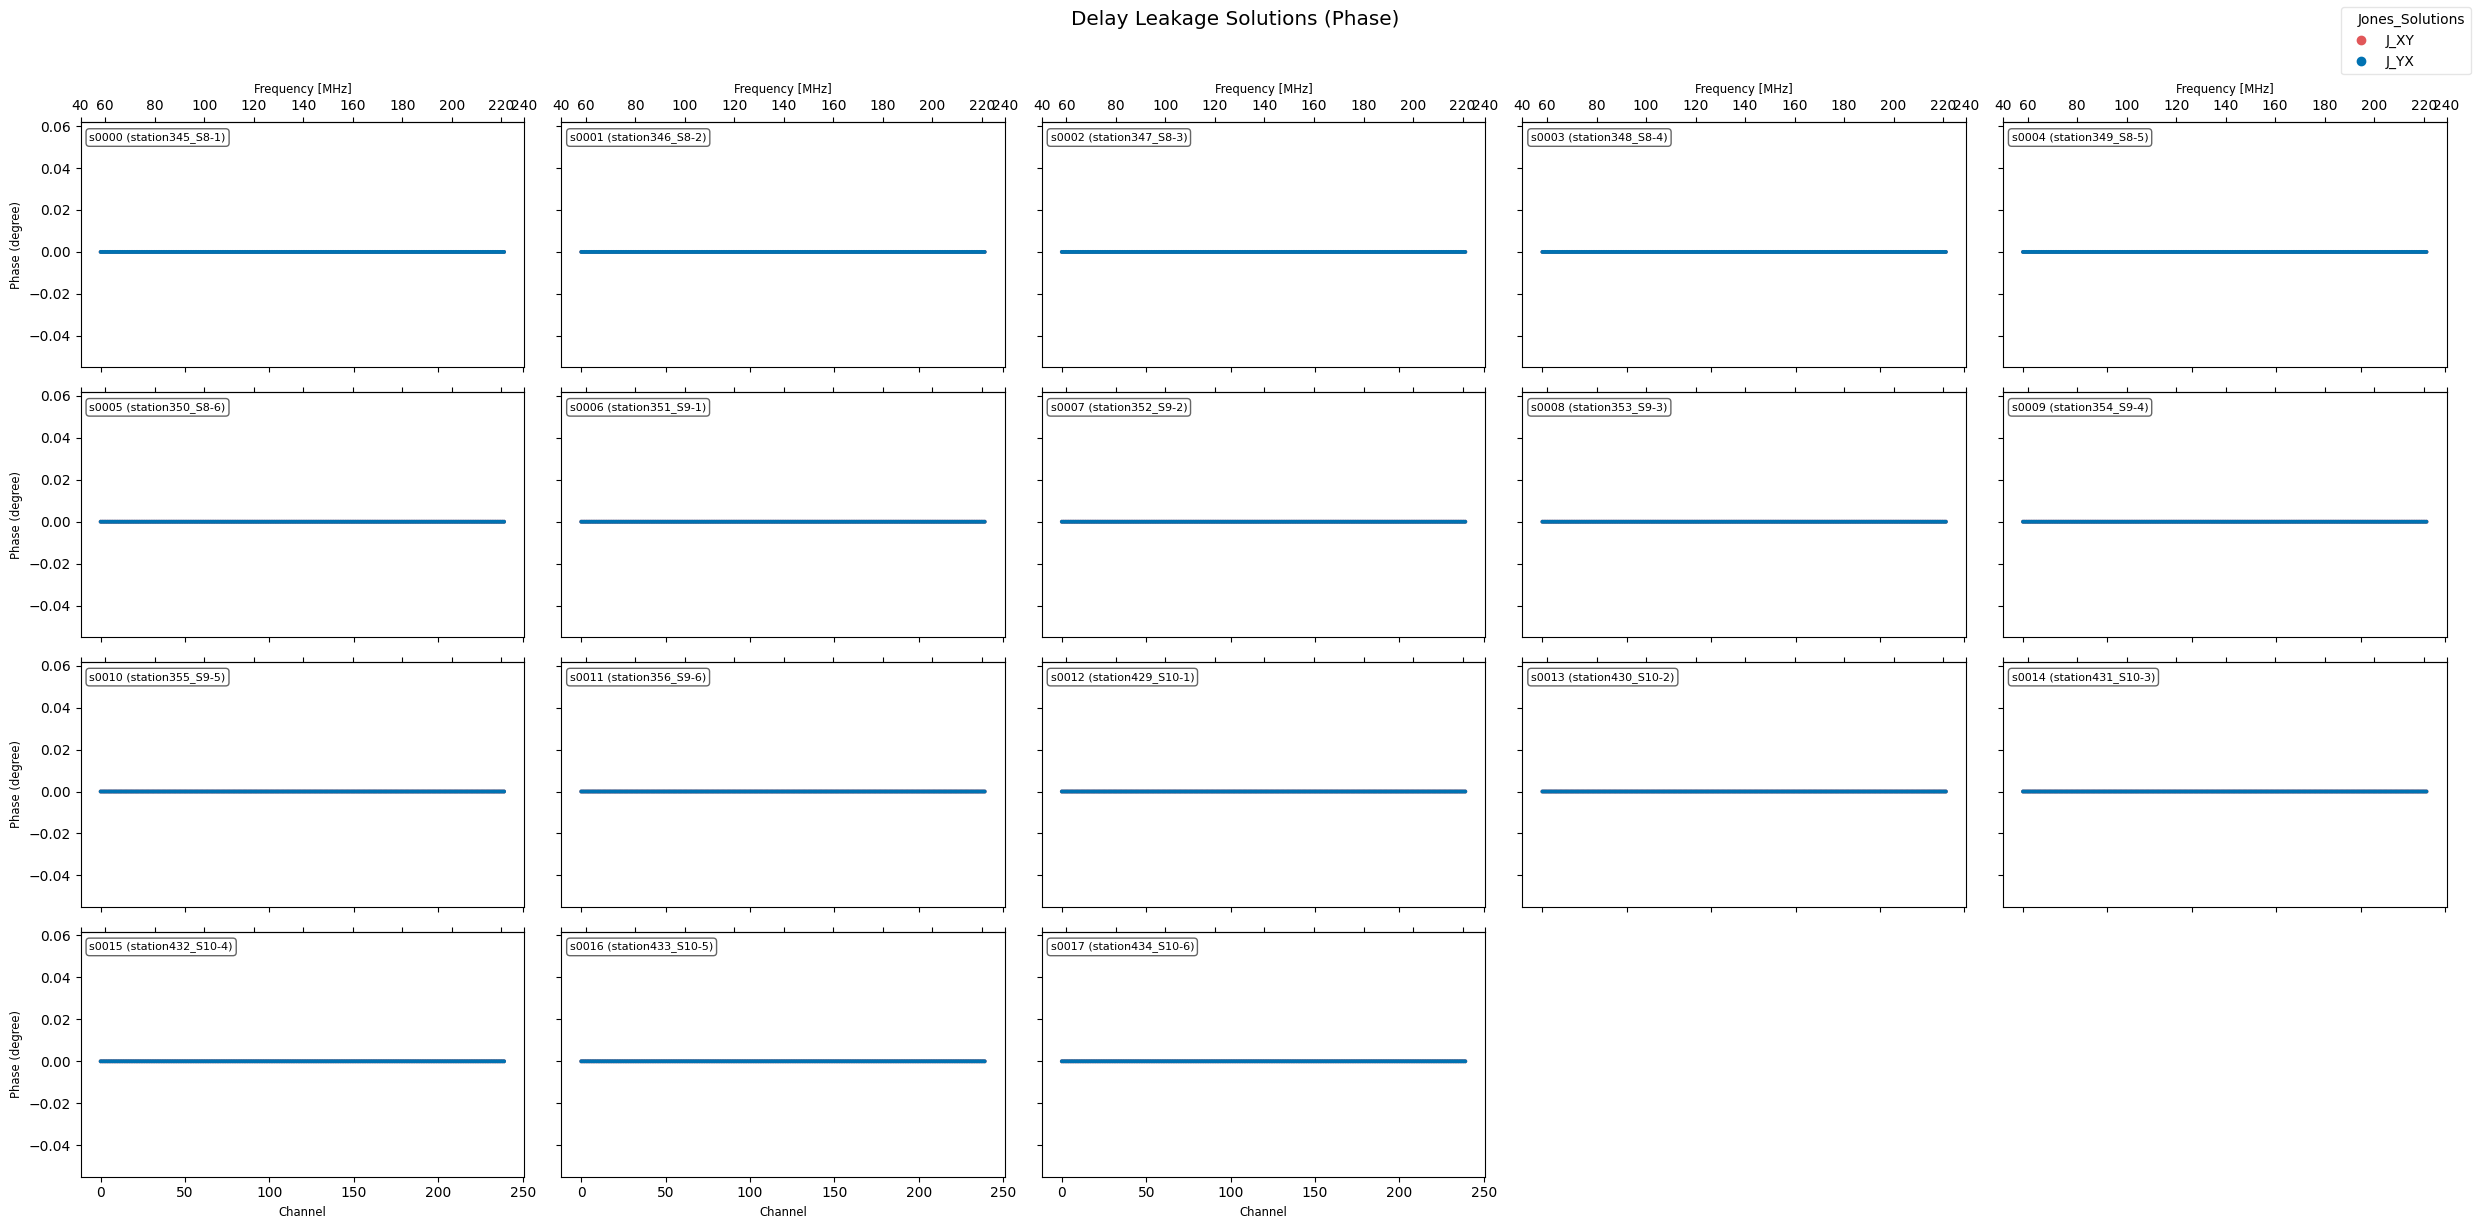

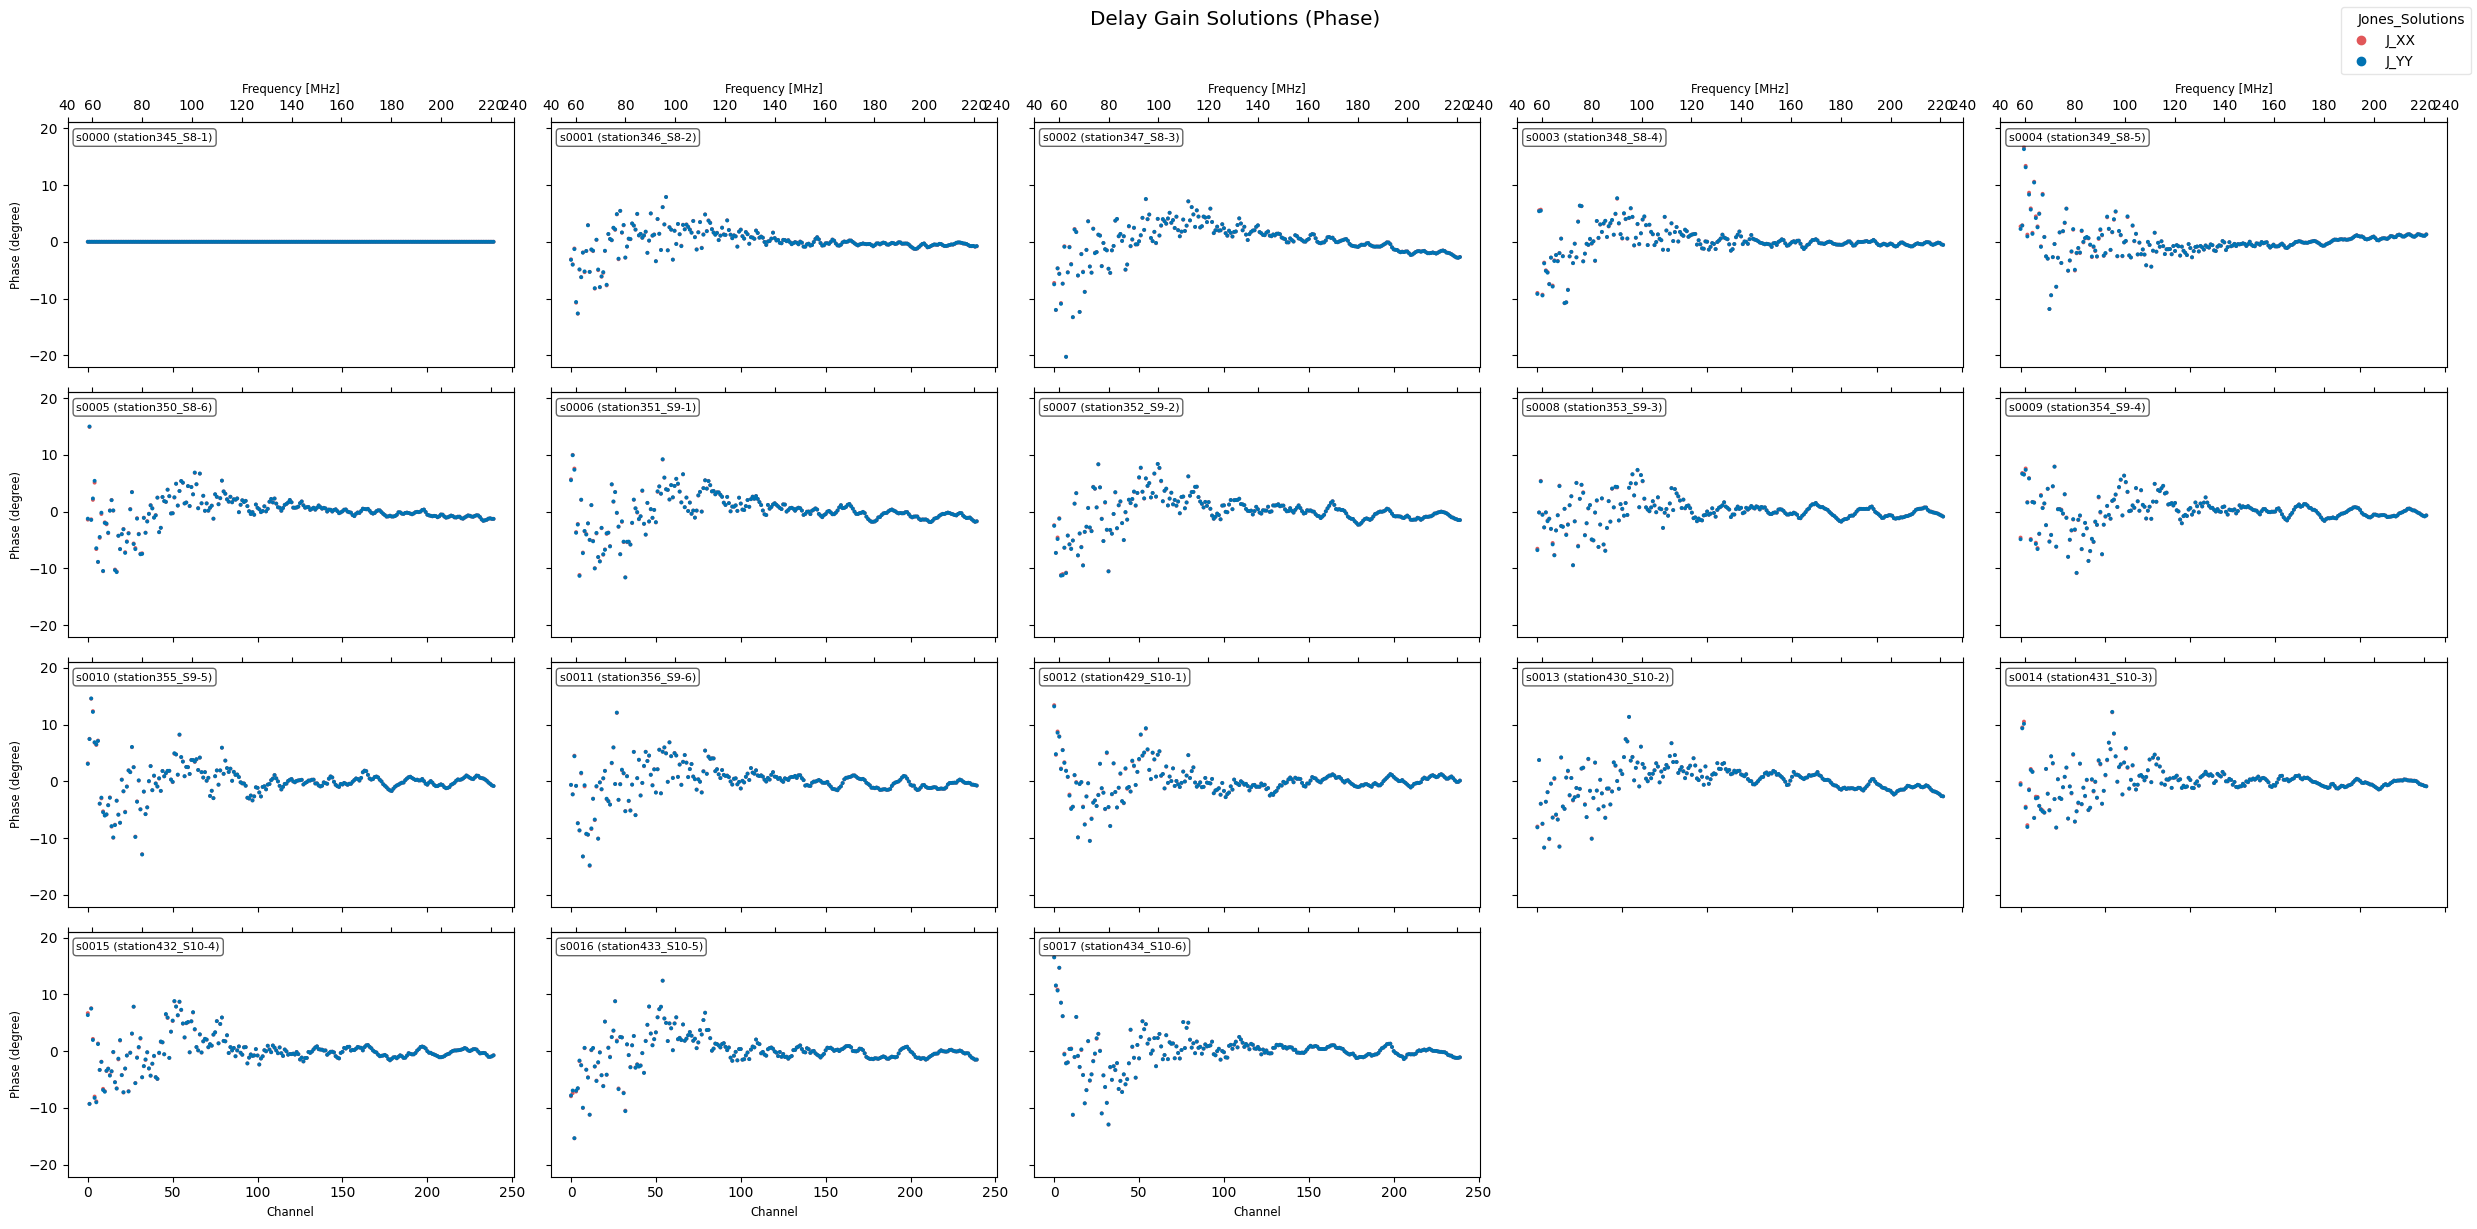

In [10]:
dask.compute(*xx.compute_tasks[:3])

/home/justin/miniconda3/envs/inst/lib/python3.10/site-packages/matplotlib/colors.py:2243: UserWarning: Warning: converting a masked element to nan.
  dtype = np.min_scalar_type(value)
/home/justin/miniconda3/envs/inst/lib/python3.10/site-packages/matplotlib/colors.py:2250: UserWarning: Warning: converting a masked element to nan.
  data = np.asarray(value)


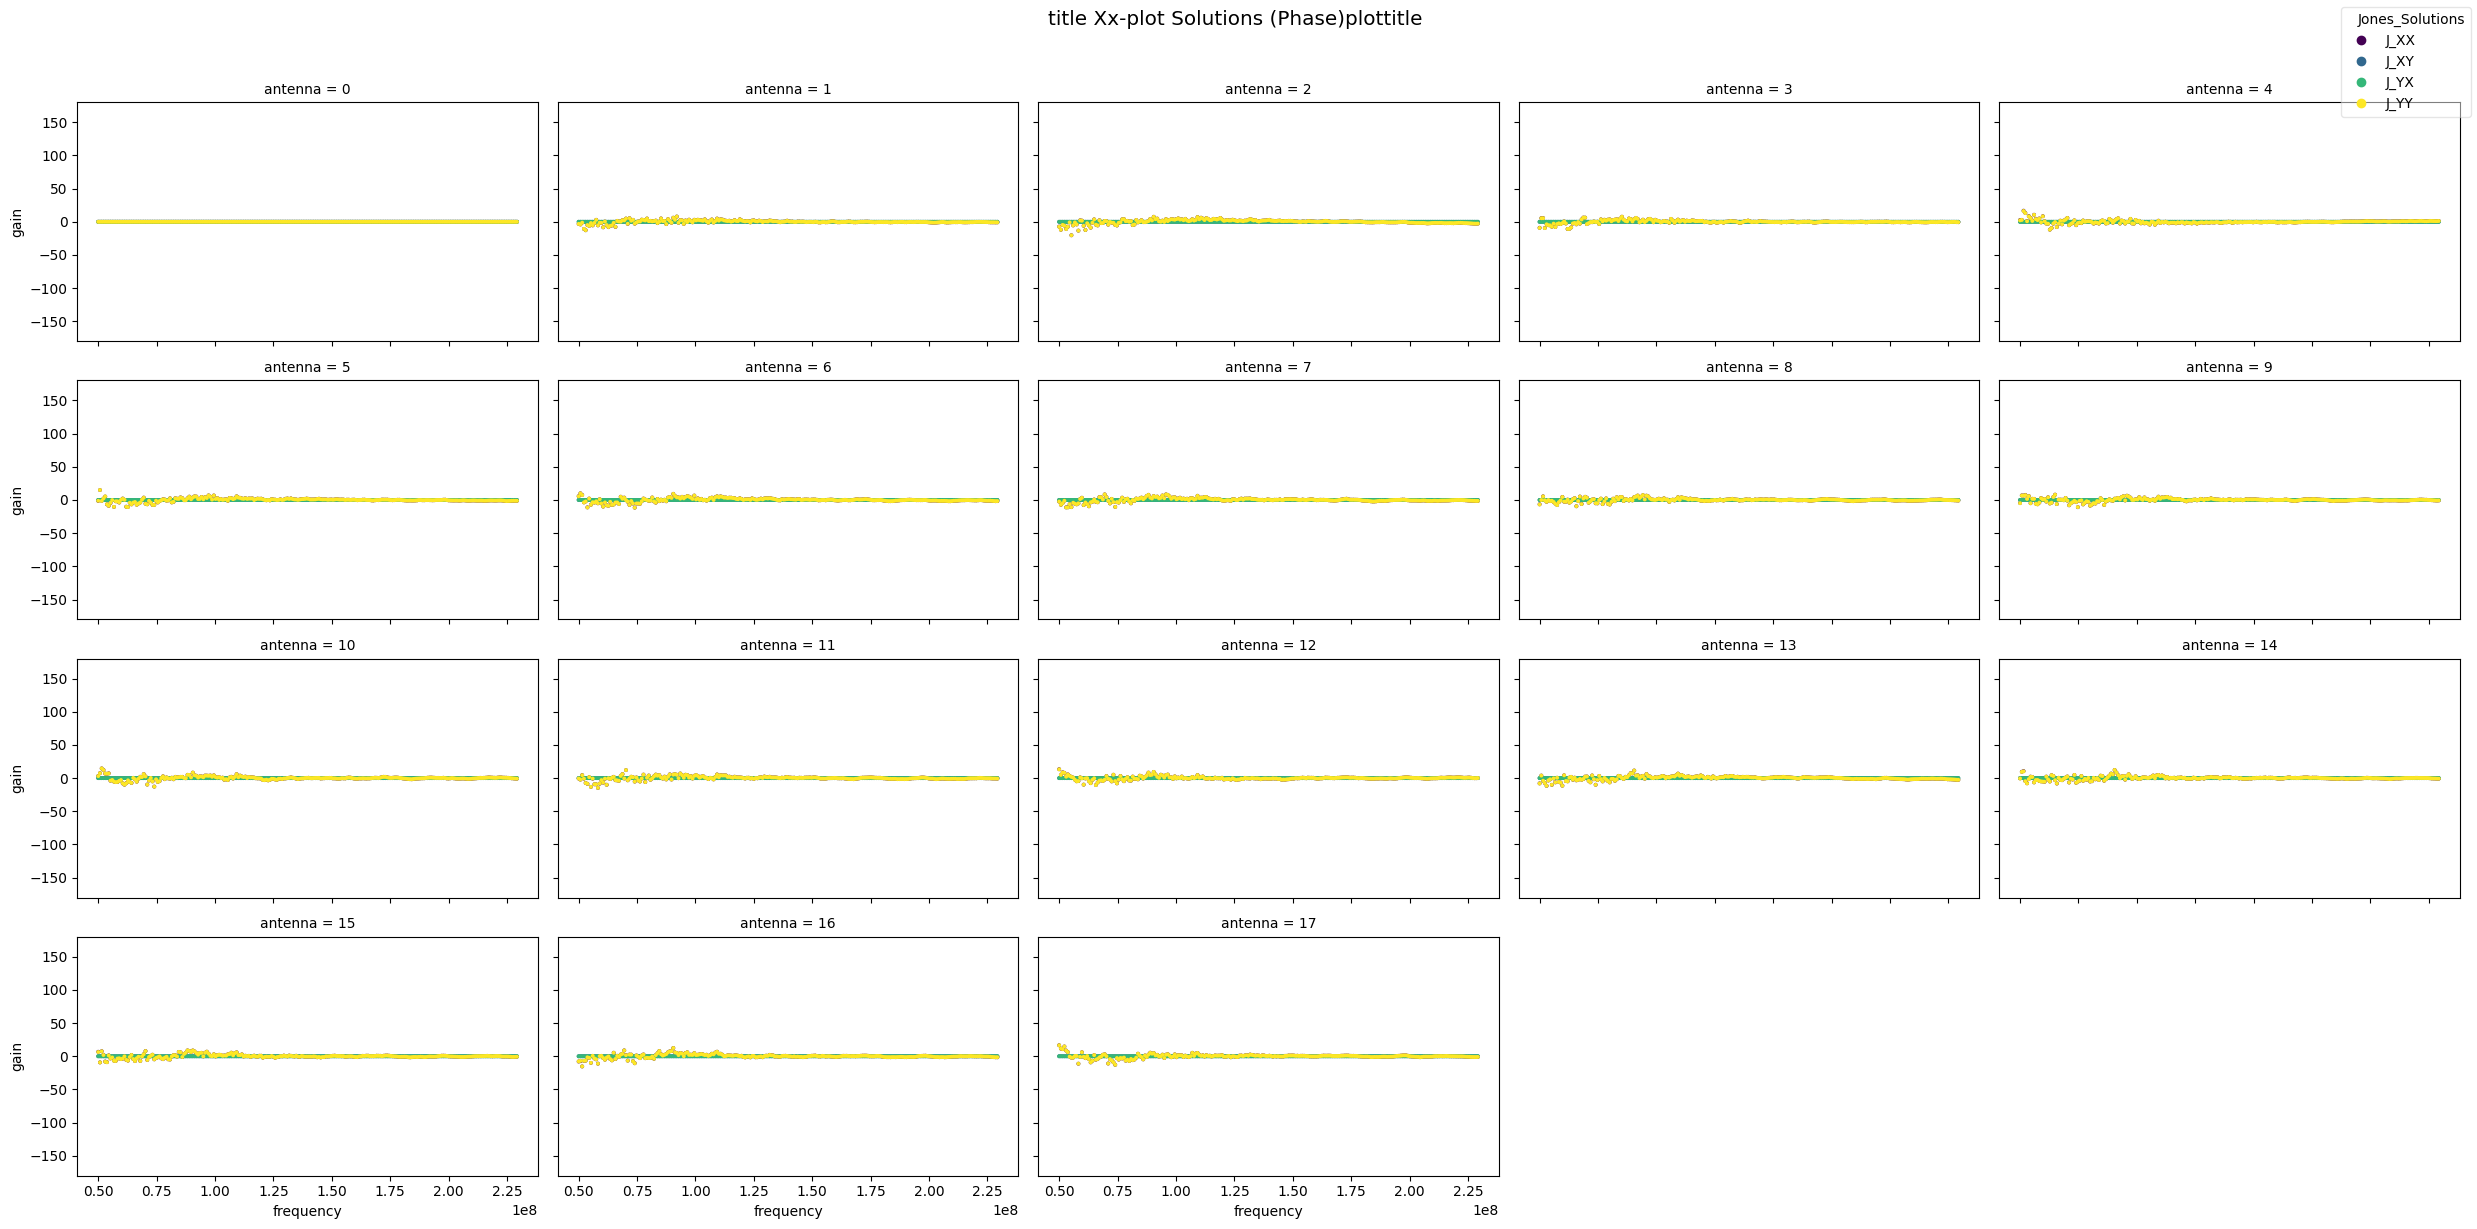

In [14]:
gaintable_fin = stack_jones_coordinate(upstream_output["gaintable"])
plot_bandpass_terms(gaintable_fin, "title", output_dir)

In [29]:
a = np.array([[[1.1, 2.1], [1.2, 2.2]]])
a.shape

(1, 2, 2)

In [21]:
b = np.array([[[["XX_1", 0], [0, "YY_1"] ], [["XX_2", 0], [0, "YY_2"] ]]])
b.shape

(1, 2, 2, 2)

In [22]:
b

array([[[['XX_1', '0'],
         ['0', 'YY_1']],

        [['XX_2', '0'],
         ['0', 'YY_2']]]], dtype='<U21')

In [23]:
a

array([[['XX_1', 'YY_1'],
        ['XX_2', 'YY_2']]], dtype='<U4')

In [30]:
c = np.zeros(b.shape)
c[..., 0, 0] = a[..., 0]
c[..., 1, 1] = a[..., 1]
c

array([[[[1.1, 0. ],
         [0. , 2.1]],

        [[1.2, 0. ],
         [0. , 2.2]]]])

In [31]:
og_gaintable

<xarray.GainTable> Size: 213kB
Dimensions:    (time: 1, antenna: 18, frequency: 240, receptor1: 2, receptor2: 2)
Coordinates:
  * time       (time) float64 8B 4.454e+09
  * antenna    (antenna) int64 144B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
  * frequency  (frequency) float64 2kB 5e+07 5.075e+07 ... 2.285e+08 2.292e+08
  * receptor1  (receptor1) <U1 8B 'X' 'Y'
  * receptor2  (receptor2) <U1 8B 'X' 'Y'
Data variables:
    gain       (time, antenna, frequency, receptor1, receptor2) complex64 138kB dask.array<chunksize=(1, 18, 32, 2, 2), meta=np.ndarray>
    weight     (time, antenna, frequency, receptor1, receptor2) float32 69kB dask.array<chunksize=(1, 18, 32, 2, 2), meta=np.ndarray>
    residual   (time, frequency, receptor1, receptor2) float32 4kB dask.array<chunksize=(1, 32, 2, 2), meta=np.ndarray>
    interval   (time) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    datetime   (time) datetime64[ns] 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    data_model:            GainTable
    receptor_frame1:       <ska_sdp_datamodels.science_data_model.polarisatio...
    receptor_frame2:       <ska_sdp_datamodels.science_data_model.polarisatio...
    phasecentre:           <SkyCoord (ICRS): (ra, dec) in deg\n    (197.91461...
    configuration:         <xarray.Configuration> Size: 4kB\nDimensions:   (i...
    jones_type:            B
    soln_interval_slices:  [slice(np.int64(0), np.int64(20), np.int64(1))]

In [35]:
gaintable.gain.shape

(1, 18, 240, 2, 2)